<a href="https://colab.research.google.com/github/njwbilll/Tugas-1_Introduction-to-Machine-Learning-with-Python-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/05_Model_Evaluation_and_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Evaluasi Model dan Peningkatan Performa

**Referensi:** Introduction to Machine Learning with Python -- Andreas C. Muller & Sarah Guido (O'Reilly)

---

## Ringkasan Chapter

Mengevaluasi dan meningkatkan performa model adalah inti dari workflow machine learning.
Chapter ini membahas cara memilih metrik yang tepat, teknik cross-validation yang benar,
dan metode pencarian hyperparameter yang efektif.

**Topik yang dibahas:**
- Cross-validation: k-fold, stratified, shuffle-split
- Grid Search dan Random Search untuk hyperparameter tuning
- Metrik evaluasi klasifikasi biner: confusion matrix, precision, recall, F1, ROC-AUC
- Metrik evaluasi multiclass
- Metrik evaluasi regresi: R2, MSE, RMSE, MAE
- Memilih metrik yang tepat untuk masalah yang tepat


## 5.0 Import Library

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    StratifiedKFold, ShuffleSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
cancer = load_breast_cancer()
print("Library berhasil diimport.")


Library berhasil diimport.


## 5.1 Cross-Validation

### Masalah dengan Single Train-Test Split

Split tunggal memberikan estimasi performa yang bergantung pada "keberuntungan"
dalam pembagian data. Jika data dibagi secara tidak menguntungkan,
estimasi bisa sangat berbeda dari performa sebenarnya.

### k-Fold Cross-Validation

Solusinya adalah mengulangi proses evaluasi beberapa kali dengan split berbeda.

**Prosedur k-Fold CV:**
1. Bagi data menjadi k bagian (fold) yang sama besar
2. Untuk setiap fold ke-i:
   - Latih model pada k-1 fold lainnya
   - Evaluasi pada fold ke-i
3. Rata-ratakan k skor evaluasi

Hasilnya adalah estimasi performa yang lebih stabil dan menggunakan
semua data baik untuk training maupun evaluasi.

**Pemilihan k:**
- k=5: kompromi yang baik antara akurasi estimasi dan biaya komputasi
- k=10: sedikit lebih akurat tapi 2x lebih lama
- k=n (Leave-One-Out / LOO): paling tidak bias tapi sangat mahal

**Stratified k-Fold:**
Untuk klasifikasi, setiap fold harus memiliki proporsi kelas yang sama
dengan dataset asli. Ini mencegah fold yang kebetulan berisi satu kelas saja.
scikit-learn menggunakan Stratified k-Fold secara otomatis untuk classifier.


In [24]:
# Basic cross-validation dengan cross_val_score
svc = SVC(kernel="rbf", C=1, gamma="scale")
scores = cross_val_score(svc, cancer.data, cancer.target, cv=5, scoring="accuracy")

print("=== 5-Fold Cross-Validation pada Breast Cancer ===")
print(f"Skor per fold: {scores.round(4)}")
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Std deviation: {scores.std():.4f}")
print(f"Interval 95%: [{scores.mean()-2*scores.std():.4f}, {scores.mean()+2*scores.std():.4f}]")
print()
print("Std deviation menunjukkan seberapa konsisten performa model")
print("di berbagai subset data.")


=== 5-Fold Cross-Validation pada Breast Cancer ===
Skor per fold: [0.8509 0.8947 0.9298 0.9474 0.9381]
Mean accuracy: 0.9122
Std deviation: 0.0354
Interval 95%: [0.8413, 0.9831]

Std deviation menunjukkan seberapa konsisten performa model
di berbagai subset data.


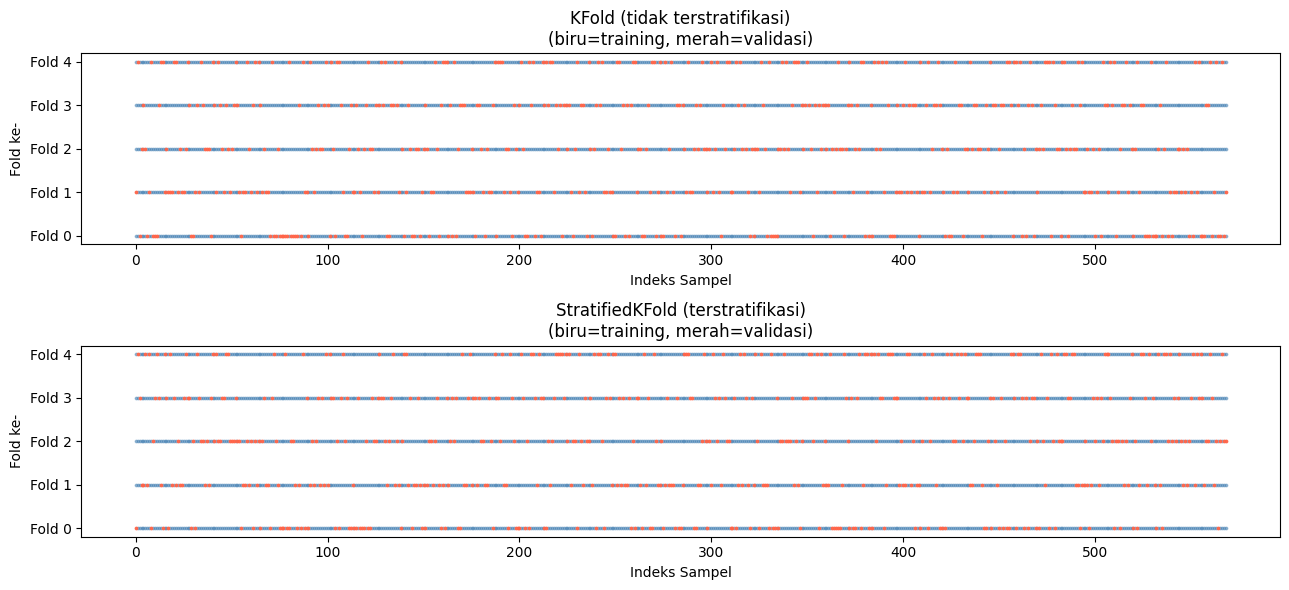

In [25]:
# Visualisasi bagaimana fold dibagi
from sklearn.model_selection import StratifiedKFold, KFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf  = KFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

for ax, cv_obj, title in zip(axes,
    [kf, skf],
    ["KFold (tidak terstratifikasi)", "StratifiedKFold (terstratifikasi)"]):

    for fold, (tr_idx, val_idx) in enumerate(cv_obj.split(cancer.data, cancer.target)):
        ax.scatter(tr_idx,  [fold]*len(tr_idx),  color="steelblue", s=3, alpha=0.5)
        ax.scatter(val_idx, [fold]*len(val_idx),  color="tomato",    s=3, alpha=0.9)

    ax.set_xlabel("Indeks Sampel")
    ax.set_ylabel("Fold ke-")
    ax.set_title(f"{title}\n(biru=training, merah=validasi)")
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"Fold {i}" for i in range(5)])

plt.tight_layout()
plt.show()


In [26]:
# Perbandingan berbagai jenis cross-validation
from sklearn.model_selection import LeaveOneOut, ShuffleSplit

cv_methods = {
    "KFold (k=5)":            KFold(n_splits=5, shuffle=True, random_state=42),
    "StratifiedKFold (k=5)":  StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "KFold (k=10)":           KFold(n_splits=10, shuffle=True, random_state=42),
    "ShuffleSplit (10x20%)":  ShuffleSplit(n_splits=10, test_size=0.2, random_state=42),
}

svc_cv = SVC(kernel="rbf", C=10, gamma=0.01)

print(f"{'Metode CV':<30} {'Mean Acc':>10} {'Std':>8} {'n splits':>10}")
print("-" * 62)
for name, cv in cv_methods.items():
    sc = cross_val_score(svc_cv, cancer.data, cancer.target, cv=cv, scoring="accuracy")
    print(f"{name:<30} {sc.mean():>10.4f} {sc.std():>8.4f} {len(sc):>10}")


Metode CV                        Mean Acc      Std   n splits
--------------------------------------------------------------
KFold (k=5)                        0.6326   0.0281          5
StratifiedKFold (k=5)              0.6292   0.0056          5
KFold (k=10)                       0.6362   0.0751         10
ShuffleSplit (10x20%)              0.6360   0.0406         10


In [27]:
# Mengapa stratified penting: contoh kasus ekstrem
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(n_samples=100, n_features=5,
                                     weights=[0.95, 0.05], random_state=42)

print("Dataset dengan class imbalance berat:")
print(f"  Kelas 0: {np.sum(y_imb==0)} sampel (95%)")
print(f"  Kelas 1: {np.sum(y_imb==1)} sampel (5%)")
print()

kf_plain = KFold(n_splits=5, shuffle=True, random_state=0)
skf_plain = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

print("Distribusi kelas 1 di setiap fold:")
print(f"{'Fold':>6} {'KFold':>15} {'StratifiedKFold':>18}")
print("-" * 42)
for fold, ((_, vi_kf), (_, vi_skf)) in enumerate(
        zip(kf_plain.split(X_imb, y_imb), skf_plain.split(X_imb, y_imb))):
    pct_kf  = y_imb[vi_kf].mean() * 100
    pct_skf = y_imb[vi_skf].mean() * 100
    print(f"{fold:>6} {pct_kf:>13.1f}%  {pct_skf:>16.1f}%")

print()
print("StratifiedKFold menjaga proporsi kelas konsisten di setiap fold.")


Dataset dengan class imbalance berat:
  Kelas 0: 95 sampel (95%)
  Kelas 1: 5 sampel (5%)

Distribusi kelas 1 di setiap fold:
  Fold           KFold    StratifiedKFold
------------------------------------------
     0           0.0%               5.0%
     1          10.0%               5.0%
     2           5.0%               5.0%
     3           5.0%               5.0%
     4           5.0%               5.0%

StratifiedKFold menjaga proporsi kelas konsisten di setiap fold.


## 5.2 Grid Search untuk Hyperparameter Tuning

### Masalah: Memilih Hyperparameter

Hyperparameter (seperti C dan gamma di SVM) tidak dipelajari dari data --
harus ditentukan sebelum training. Pilihan yang salah bisa menghasilkan
model yang sangat buruk.

### Naive Approach (SALAH): Coba di Test Set

Jika kita memilih hyperparameter berdasarkan performa di test set,
kita secara tidak langsung "melatih" model pada test set.
Test accuracy menjadi terlalu optimistik dan tidak mencerminkan
performa pada data baru yang benar-benar belum terlihat.

### Pendekatan Benar: GridSearchCV

GridSearchCV mencoba semua kombinasi hyperparameter yang ditentukan
menggunakan cross-validation pada data training saja.
Test set tetap tersimpan untuk evaluasi akhir yang jujur.

**Prosedur yang benar:**
1. Split data menjadi train dan test (test disimpan, tidak disentuh)
2. GridSearchCV pada train set: mencoba semua kombinasi via CV
3. Pilih hyperparameter terbaik berdasarkan CV score
4. Latih ulang model dengan hyperparameter terbaik pada SELURUH train set
5. Evaluasi SEKALI pada test set

### Random Search

Alih-alih mencoba semua kombinasi (exhaustive), Random Search
mengambil sampel acak dari ruang hyperparameter.
Ini lebih efisien ketika ruang pencarian besar dan tidak semua
hyperparameter sama pentingnya.


In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Setup: bagi data dengan test set yang disimpan
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, random_state=0, stratify=cancer.target)

# Scale fitur (fit hanya pada train)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

# Grid search
param_grid = {
    "C":     [0.001, 0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
}

grid_search = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_tr_sc, y_tr)

print("=== GridSearchCV: RBF SVM pada Breast Cancer ===")
print(f"Parameter terbaik  : {grid_search.best_params_}")
print(f"CV accuracy terbaik: {grid_search.best_score_:.4f}")
print(f"Test accuracy      : {grid_search.score(X_te_sc, y_te):.4f}")
print()
print("Test accuracy hanya dihitung SEKALI di akhir dengan parameter terbaik.")


=== GridSearchCV: RBF SVM pada Breast Cancer ===
Parameter terbaik  : {'C': 100, 'gamma': 0.001}
CV accuracy terbaik: 0.9883
Test accuracy      : 0.9580

Test accuracy hanya dihitung SEKALI di akhir dengan parameter terbaik.


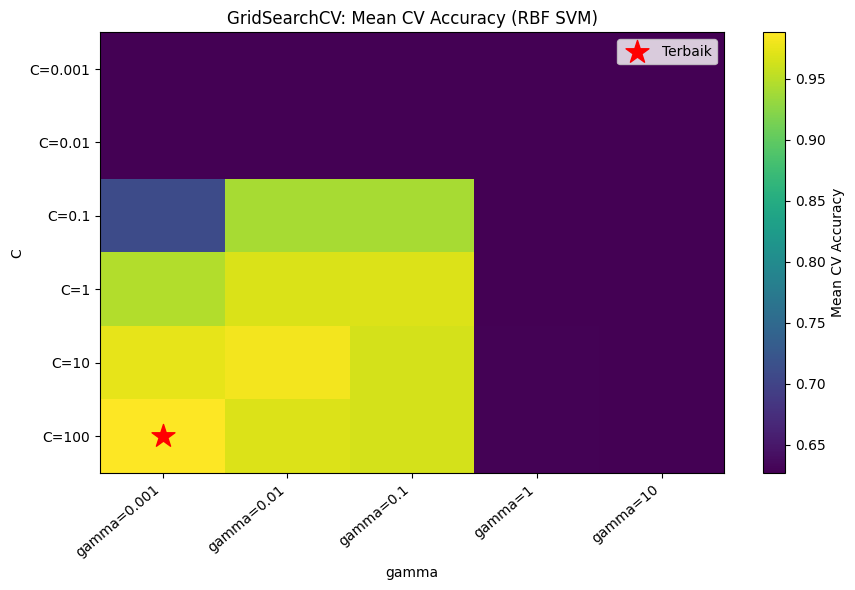

Parameter terbaik: C=100, gamma=0.001


In [29]:
# Heatmap hasil grid search
results_gs = pd.DataFrame(grid_search.cv_results_)
mean_test_scores = results_gs["mean_test_score"].values.reshape(
    len(param_grid["C"]), len(param_grid["gamma"]))

plt.figure(figsize=(9, 6))
plt.imshow(mean_test_scores, interpolation="nearest", cmap="viridis",
           aspect="auto")
plt.colorbar(label="Mean CV Accuracy")
plt.xticks(range(len(param_grid["gamma"])),
           [f"gamma={g}" for g in param_grid["gamma"]], rotation=40, ha="right")
plt.yticks(range(len(param_grid["C"])),
           [f"C={c}" for c in param_grid["C"]])
plt.title("GridSearchCV: Mean CV Accuracy (RBF SVM)")
plt.xlabel("gamma")
plt.ylabel("C")

# Tandai parameter terbaik
best_C_idx     = param_grid["C"].index(grid_search.best_params_["C"])
best_gamma_idx = param_grid["gamma"].index(grid_search.best_params_["gamma"])
plt.scatter(best_gamma_idx, best_C_idx, marker="*", s=300,
            color="red", zorder=5, label="Terbaik")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Parameter terbaik: C={grid_search.best_params_['C']}, "
      f"gamma={grid_search.best_params_['gamma']}")


In [30]:
# Random Search: lebih efisien untuk ruang pencarian besar
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    "C":     loguniform(0.001, 1000),
    "gamma": loguniform(0.0001, 100),
}

rand_search = RandomizedSearchCV(
    SVC(kernel="rbf"),
    param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
rand_search.fit(X_tr_sc, y_tr)

print("=== RandomizedSearchCV (50 iterasi) ===")
print(f"Parameter terbaik  : C={rand_search.best_params_['C']:.4f}, "
      f"gamma={rand_search.best_params_['gamma']:.6f}")
print(f"CV accuracy terbaik: {rand_search.best_score_:.4f}")
print(f"Test accuracy      : {rand_search.score(X_te_sc, y_te):.4f}")
print()
print("GridSearchCV mencoba 6x5=30 kombinasi.")
print("RandomizedSearchCV mencoba 50 kombinasi dari distribusi kontinu.")
print("Untuk ruang parameter besar, Random Search seringkali lebih efisien.")


=== RandomizedSearchCV (50 iterasi) ===
Parameter terbaik  : C=43.0000, gamma=0.001557
CV accuracy terbaik: 0.9883
Test accuracy      : 0.9510

GridSearchCV mencoba 6x5=30 kombinasi.
RandomizedSearchCV mencoba 50 kombinasi dari distribusi kontinu.
Untuk ruang parameter besar, Random Search seringkali lebih efisien.


In [31]:
# GridSearchCV di dalam Pipeline (cara yang benar)
from sklearn.pipeline import Pipeline

pipe_gs = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf")),
])

param_grid_pipe = {
    "svm__C":     [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
}

grid_pipe = GridSearchCV(pipe_gs, param_grid_pipe, cv=5, n_jobs=-1)
grid_pipe.fit(X_tr, y_tr)  # Gunakan X_tr yang BELUM discale -- pipeline yg scale

print("=== GridSearchCV + Pipeline ===")
print(f"Parameter terbaik: {grid_pipe.best_params_}")
print(f"CV accuracy      : {grid_pipe.best_score_:.4f}")
print(f"Test accuracy    : {grid_pipe.score(X_te, y_te):.4f}")
print()
print("Dengan Pipeline, scaling di-fit ulang untuk setiap fold CV secara otomatis.")
print("Ini mencegah data leakage dari scaling.")


=== GridSearchCV + Pipeline ===
Parameter terbaik: {'svm__C': 100, 'svm__gamma': 0.001}
CV accuracy      : 0.9883
Test accuracy    : 0.9580

Dengan Pipeline, scaling di-fit ulang untuk setiap fold CV secara otomatis.
Ini mencegah data leakage dari scaling.


## 5.3 Metrik Evaluasi untuk Klasifikasi Biner

### Mengapa Accuracy Tidak Selalu Cukup?

Bayangkan dataset deteksi penipuan dengan 99% transaksi normal dan 1% fraud.
Model yang selalu prediksi "normal" akan punya accuracy 99%, tapi tidak berguna sama sekali.

### Confusion Matrix

Confusion matrix adalah tabel yang menunjukkan:

|                | Prediksi Positif | Prediksi Negatif |
|----------------|-----------------|-----------------|
| Aktual Positif | TP (True Positive) | FN (False Negative) |
| Aktual Negatif | FP (False Positive) | TN (True Negative) |

**TP** (True Positive): prediksi positif yang benar (fraud diprediksi fraud)
**TN** (True Negative): prediksi negatif yang benar (normal diprediksi normal)
**FP** (False Positive): prediksi positif yang salah (normal diprediksi fraud) -- Type I Error
**FN** (False Negative): prediksi negatif yang salah (fraud diprediksi normal) -- Type II Error

### Metrik Turunan dari Confusion Matrix

**Precision** = TP / (TP + FP)
Dari semua yang diprediksi positif, berapa yang benar-benar positif?
"Seberapa akurat prediksi positif kita?"

**Recall (Sensitivity / TPR)** = TP / (TP + FN)
Dari semua yang benar-benar positif, berapa yang berhasil kita deteksi?
"Seberapa banyak kasus positif yang berhasil kita tangkap?"

**F1 Score** = 2 * (Precision * Recall) / (Precision + Recall)
Rata-rata harmonik precision dan recall. Berguna ketika butuh keseimbangan keduanya.

**Precision vs Recall Trade-off:**
Meningkatkan threshold klasifikasi --> Precision naik, Recall turun.
Menurunkan threshold --> Precision turun, Recall naik.


In [32]:
# Train model untuk demonstrasi
best_svm = grid_search.best_estimator_  # SVM terbaik dari GridSearch
y_pred = best_svm.predict(X_te_sc)

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
print("=== Confusion Matrix ===")
print(cm)
print()
print(f"True Negative  (TN): {cm[0,0]}  -- normal diprediksi normal (benar)")
print(f"False Positive (FP): {cm[0,1]}  -- normal diprediksi malignant (salah)")
print(f"False Negative (FN): {cm[1,0]}  -- malignant diprediksi normal (salah)")
print(f"True Positive  (TP): {cm[1,1]}  -- malignant diprediksi malignant (benar)")
print()
print("Untuk deteksi kanker, False Negative lebih berbahaya:")
print("  FN = pasien kanker tidak terdeteksi = risiko tidak ditangani")


=== Confusion Matrix ===
[[48  5]
 [ 1 89]]

True Negative  (TN): 48  -- normal diprediksi normal (benar)
False Positive (FP): 5  -- normal diprediksi malignant (salah)
False Negative (FN): 1  -- malignant diprediksi normal (salah)
True Positive  (TP): 89  -- malignant diprediksi malignant (benar)

Untuk deteksi kanker, False Negative lebih berbahaya:
  FN = pasien kanker tidak terdeteksi = risiko tidak ditangani


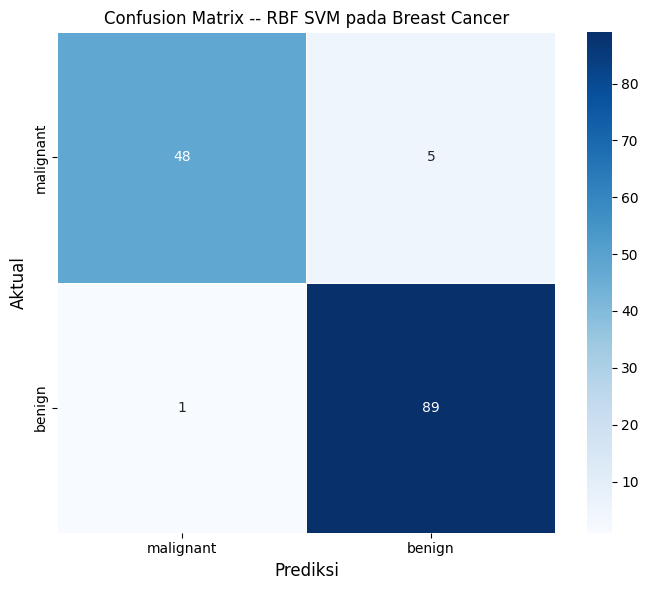

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [33]:
# Visualisasi confusion matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names,
            linewidths=0.5)
ax.set_xlabel("Prediksi", fontsize=12)
ax.set_ylabel("Aktual", fontsize=12)
ax.set_title("Confusion Matrix -- RBF SVM pada Breast Cancer")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_te, y_pred, target_names=cancer.target_names))


In [34]:
# Hitung semua metrik secara manual
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)
accuracy  = (tp + tn) / (tp + tn + fp + fn)
specificity = tn / (tn + fp)  # True Negative Rate

print("=== Metrik dari Confusion Matrix ===")
print(f"Accuracy    (ACC): {accuracy:.4f}  -- (TP+TN) / Total")
print(f"Precision   (PPV): {precision:.4f}  -- TP / (TP+FP)")
print(f"Recall      (TPR): {recall:.4f}  -- TP / (TP+FN)")
print(f"Specificity (TNR): {specificity:.4f}  -- TN / (TN+FP)")
print(f"F1 Score        : {f1:.4f}  -- 2*P*R / (P+R)")
print()
print("Verifikasi dengan scikit-learn:")
print(f"  f1_score    : {f1_score(y_te, y_pred, pos_label=1):.4f}")
print(f"  precision   : {precision_score(y_te, y_pred):.4f}")
print(f"  recall      : {recall_score(y_te, y_pred):.4f}")


=== Metrik dari Confusion Matrix ===
Accuracy    (ACC): 0.9580  -- (TP+TN) / Total
Precision   (PPV): 0.9468  -- TP / (TP+FP)
Recall      (TPR): 0.9889  -- TP / (TP+FN)
Specificity (TNR): 0.9057  -- TN / (TN+FP)
F1 Score        : 0.9674  -- 2*P*R / (P+R)

Verifikasi dengan scikit-learn:
  f1_score    : 0.9674
  precision   : 0.9468
  recall      : 0.9889


## 5.4 ROC Curve dan AUC

ROC (Receiver Operating Characteristic) Curve memplot:
- Sumbu X: False Positive Rate (FPR) = FP / (FP + TN)
- Sumbu Y: True Positive Rate (TPR / Recall) = TP / (TP + FN)

Kurva ini dibuat dengan menggeser threshold klasifikasi dari 0 ke 1
dan menghitung FPR dan TPR di setiap threshold.

**AUC (Area Under the ROC Curve):**
- AUC = 1.0: model sempurna
- AUC = 0.5: model setara random (garis diagonal)
- AUC < 0.5: model lebih buruk dari random (tukar label prediksinya)

AUC mengukur kemampuan model untuk memisahkan kelas positif dan negatif
di semua possible threshold, sehingga tidak bergantung pada pilihan threshold.

## 5.5 Precision-Recall Curve

Precision-Recall Curve lebih informatif dari ROC ketika kelas sangat tidak seimbang.

- Sumbu X: Recall
- Sumbu Y: Precision

**Average Precision (AP):** area di bawah kurva Precision-Recall.
Berguna ketika kelas positif sangat jarang (fraud detection, anomaly detection).


ROC-AUC          : 0.9943
Average Precision: 0.9967


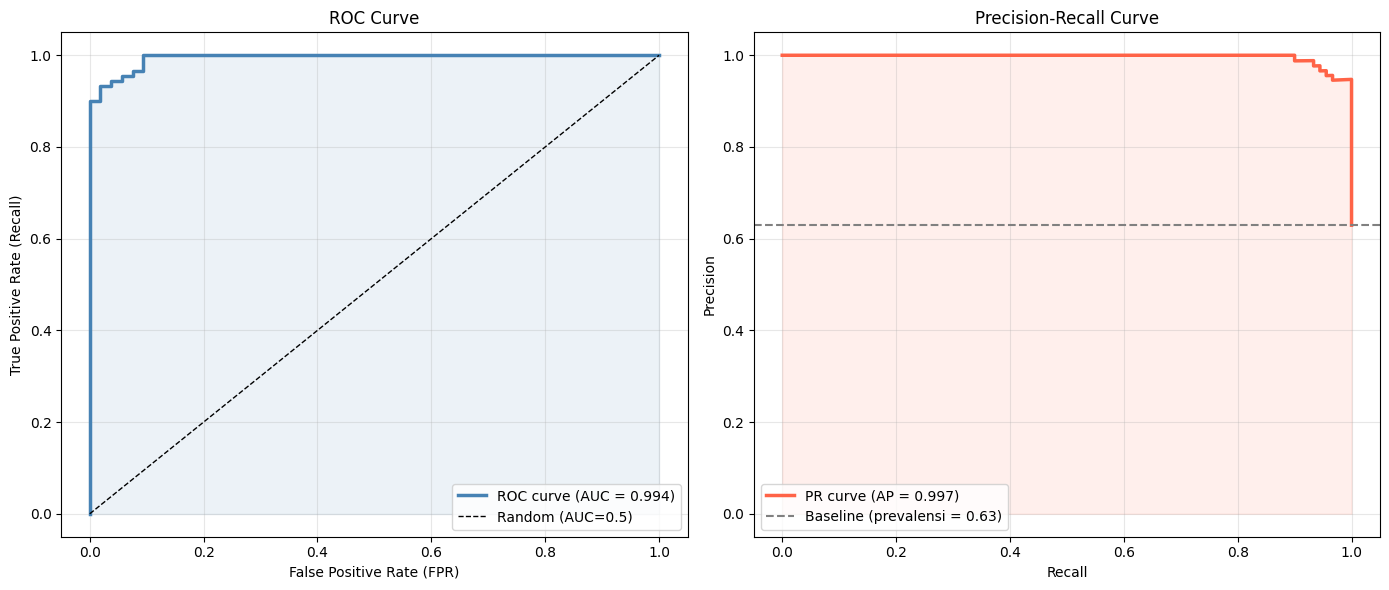

In [35]:
# Dapatkan skor keputusan dari model
dec_scores = best_svm.decision_function(X_te_sc)

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_te, dec_scores)
roc_auc_val = auc(fpr, tpr)

# Precision-Recall Curve
prec, rec, thresholds_pr = precision_recall_curve(y_te, dec_scores)
ap_val = average_precision_score(y_te, dec_scores)

print(f"ROC-AUC          : {roc_auc_val:.4f}")
print(f"Average Precision: {ap_val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color="steelblue", linewidth=2.5,
             label=f"ROC curve (AUC = {roc_auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.5)")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(rec, prec, color="tomato", linewidth=2.5,
             label=f"PR curve (AP = {ap_val:.3f})")
axes[1].axhline(y_te.mean(), color="gray", linestyle="--",
                label=f"Baseline (prevalensi = {y_te.mean():.2f})")
axes[1].fill_between(rec, prec, alpha=0.1, color="tomato")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [36]:
# Visualisasi trade-off precision-recall dengan threshold
# Pilih beberapa threshold dan tampilkan trade-off-nya
threshold_vals = [-2, -1, 0, 1, 2]

print("Trade-off Precision-Recall pada berbagai threshold:")
print(f"{'Threshold':>12} {'Precision':>12} {'Recall':>10} {'F1':>10} {'n pred pos':>12}")
print("-" * 58)

for thr in threshold_vals:
    y_pred_thr = (dec_scores >= thr).astype(int)
    if y_pred_thr.sum() == 0:
        print(f"{thr:>12} {'N/A':>12} {'N/A':>10} {'N/A':>10} {y_pred_thr.sum():>12}")
        continue
    p = precision_score(y_te, y_pred_thr, zero_division=0)
    r = recall_score(y_te, y_pred_thr, zero_division=0)
    f = f1_score(y_te, y_pred_thr, zero_division=0)
    n_pos = y_pred_thr.sum()
    print(f"{thr:>12} {p:>12.4f} {r:>10.4f} {f:>10.4f} {n_pos:>12}")

print()
print("Threshold rendah: recall tinggi (tangkap lebih banyak fraud) tapi precision rendah.")
print("Threshold tinggi: precision tinggi tapi banyak fraud terlewat.")


Trade-off Precision-Recall pada berbagai threshold:
   Threshold    Precision     Recall         F1   n pred pos
----------------------------------------------------------
          -2       0.9091     1.0000     0.9524           99
          -1       0.9278     1.0000     0.9626           97
           0       0.9468     0.9889     0.9674           94
           1       0.9881     0.9222     0.9540           84
           2       1.0000     0.7444     0.8535           67

Threshold rendah: recall tinggi (tangkap lebih banyak fraud) tapi precision rendah.
Threshold tinggi: precision tinggi tapi banyak fraud terlewat.


## 5.6 Metrik untuk Klasifikasi Multiclass

Untuk lebih dari 2 kelas, kita perlu cara untuk merata-ratakan metrik per-kelas.

**Strategi averaging:**

**Macro Average:**
Hitung metrik untuk setiap kelas secara independen, lalu ambil rata-rata tidak berbobot.
Setiap kelas mendapat bobot yang sama terlepas dari frekuensinya.
Cocok ketika semua kelas sama pentingnya.

**Weighted Average:**
Seperti macro, tapi diboboti berdasarkan jumlah sampel per kelas (support).
Kelas dengan lebih banyak sampel mendapat bobot lebih besar.
Cocok ketika frekuensi kelas mencerminkan kepentingannya.

**Micro Average:**
Agregasi TP, FP, FN dari semua kelas terlebih dahulu, baru hitung metrik.
Untuk precision, recall, dan F1: hasil sama dengan accuracy di setting multiclass.

**Confusion Matrix Multiclass:**
Matriks n x n di mana n adalah jumlah kelas. Diagonal = prediksi benar.
Off-diagonal = kesalahan (kelas mana yang sering tertukar).


In [37]:
from sklearn.datasets import load_iris

iris = load_iris()
X_itr, X_ite, y_itr, y_ite = train_test_split(
    iris.data, iris.target, random_state=0, stratify=iris.target)

# Train Random Forest
rf_iris = RandomForestClassifier(n_estimators=100, random_state=0)
rf_iris.fit(X_itr, y_itr)
y_ipred = rf_iris.predict(X_ite)

print("=== Evaluasi Multiclass (Iris, 3 Kelas) ===")
print()
print("Classification Report:")
print(classification_report(y_ite, y_ipred, target_names=iris.target_names))


=== Evaluasi Multiclass (Iris, 3 Kelas) ===

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.83      0.91        12

    accuracy                           0.95        38
   macro avg       0.96      0.94      0.95        38
weighted avg       0.95      0.95      0.95        38



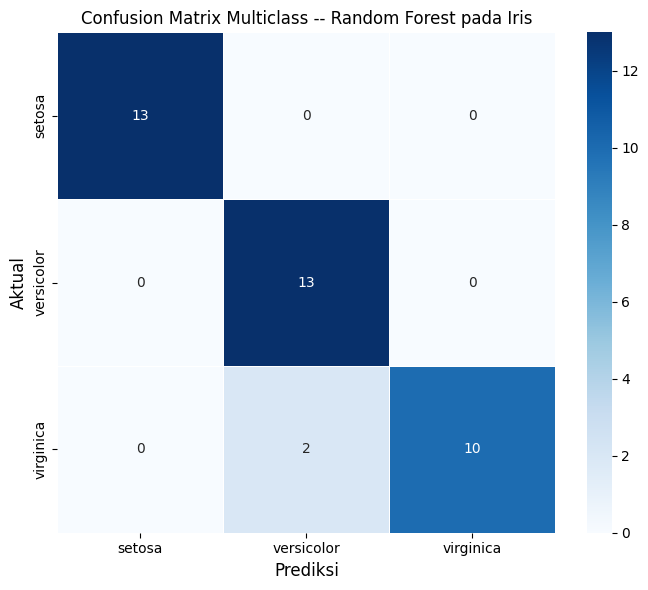

Accuracy per kelas:
  setosa: 1.0000
  versicolor: 1.0000
  virginica: 0.8333


In [38]:
# Confusion Matrix Multiclass
cm_iris = confusion_matrix(y_ite, y_ipred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_iris, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            linewidths=0.5)
plt.xlabel("Prediksi", fontsize=12)
plt.ylabel("Aktual", fontsize=12)
plt.title("Confusion Matrix Multiclass -- Random Forest pada Iris")
plt.tight_layout()
plt.show()

# Accuracy per kelas
print("Accuracy per kelas:")
for i, cls_name in enumerate(iris.target_names):
    cls_acc = cm_iris[i, i] / cm_iris[i, :].sum()
    print(f"  {cls_name}: {cls_acc:.4f}")


In [39]:
# Perbandingan averaging strategies
y_pred_mc = rf_iris.predict(X_ite)

print("=== Perbandingan Averaging Strategies ===")
print()
print(f"{'Metrik':<20} {'macro':>10} {'weighted':>12} {'micro':>10}")
print("-" * 55)

for metric_name, metric_fn in [
    ("Precision", precision_score),
    ("Recall",    recall_score),
    ("F1 Score",  f1_score),
]:
    macro    = metric_fn(y_ite, y_pred_mc, average="macro")
    weighted = metric_fn(y_ite, y_pred_mc, average="weighted")
    micro    = metric_fn(y_ite, y_pred_mc, average="micro")
    print(f"{metric_name:<20} {macro:>10.4f} {weighted:>12.4f} {micro:>10.4f}")

print()
print("Pada dataset seimbang seperti Iris, ketiga averaging menghasilkan nilai mirip.")


=== Perbandingan Averaging Strategies ===

Metrik                    macro     weighted      micro
-------------------------------------------------------
Precision                0.9556       0.9544     0.9474
Recall                   0.9444       0.9474     0.9474
F1 Score                 0.9459       0.9469     0.9474

Pada dataset seimbang seperti Iris, ketiga averaging menghasilkan nilai mirip.


## 5.7 Metrik Evaluasi untuk Regresi

Untuk regresi, kita tidak bisa menggunakan accuracy. Metrik regresi mengukur
seberapa jauh prediksi dari nilai aktual.

**R2 (Coefficient of Determination)**
Proporsi variansi target yang dijelaskan oleh model.
- R2 = 1.0: prediksi sempurna
- R2 = 0.0: model sama baiknya dengan prediksi rata-rata
- R2 < 0: model lebih buruk dari prediksi rata-rata

**MSE (Mean Squared Error)**
Rata-rata kuadrat error. Menghukum error besar lebih berat.
Dalam satuan kuadrat dari target.

**RMSE (Root Mean Squared Error)**
Akar dari MSE. Dalam satuan yang sama dengan target.
Lebih mudah diinterpretasi daripada MSE.

**MAE (Mean Absolute Error)**
Rata-rata nilai absolut error. Lebih robust terhadap outlier.
Dalam satuan yang sama dengan target.

**Kapan menggunakan yang mana:**
- R2: untuk perbandingan relatif antar model (tidak bergantung skala)
- RMSE: ketika error besar lebih merugikan (housing price, medical)
- MAE: ketika semua error sama pentingnya, ada outlier banyak


In [40]:
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge

X_reg, y_reg = make_regression(n_samples=300, n_features=10,
                                 noise=30, random_state=42)
X_rtr, X_rte, y_rtr, y_rte = train_test_split(X_reg, y_reg, random_state=0)

models_reg = {
    "Ridge":              Ridge(alpha=1),
    "GradientBoosting":   GradientBoostingRegressor(n_estimators=100, random_state=0),
    "RandomForest":       RandomForestClassifier(n_estimators=100, random_state=0),
}

from sklearn.ensemble import RandomForestRegressor
models_reg["RandomForest"] = RandomForestRegressor(n_estimators=100, random_state=0)

print(f"{'Model':<22} {'R2':>8} {'MSE':>12} {'RMSE':>10} {'MAE':>10}")
print("-" * 65)

metrics_reg = {}
for name, model in models_reg.items():
    model.fit(X_rtr, y_rtr)
    y_hat = model.predict(X_rte)
    r2   = r2_score(y_rte, y_hat)
    mse  = mean_squared_error(y_rte, y_hat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_rte, y_hat)
    metrics_reg[name] = {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}
    print(f"{name:<22} {r2:>8.4f} {mse:>12.2f} {rmse:>10.2f} {mae:>10.2f}")


Model                        R2          MSE       RMSE        MAE
-----------------------------------------------------------------
Ridge                    0.9701      1032.64      32.13      26.58
GradientBoosting         0.7972      7001.36      83.67      65.27
RandomForest             0.6822     10969.80     104.74      78.66


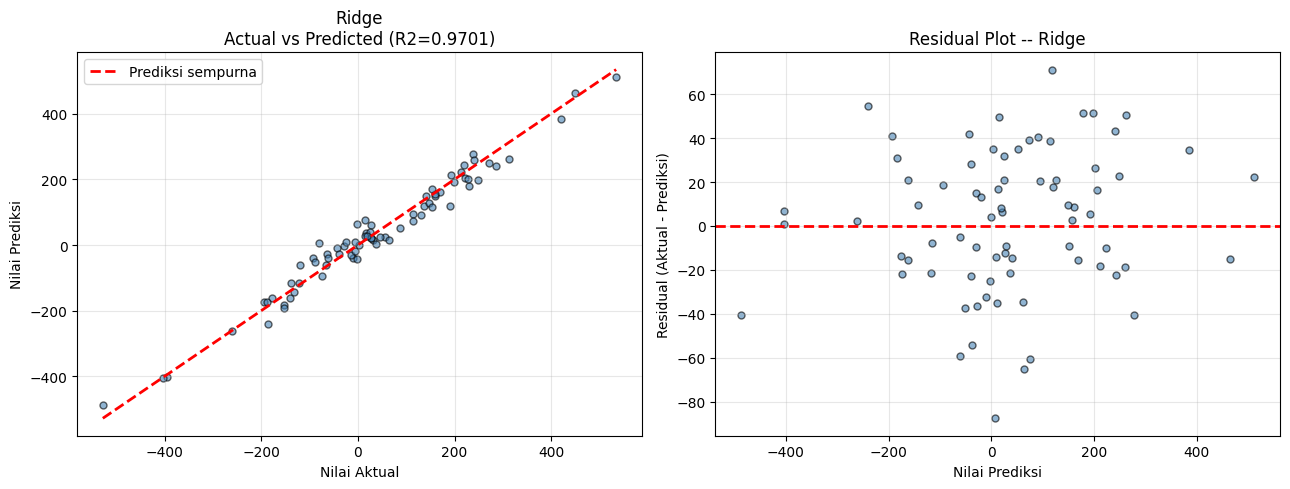

Residual plot yang baik: titik-titik tersebar acak di sekitar garis nol.
Pola pada residual menunjukkan model masih melewatkan struktur dalam data.


In [41]:
# Visualisasi actual vs predicted untuk model terbaik
best_reg_name = max(metrics_reg, key=lambda n: metrics_reg[n]["R2"])
best_reg = models_reg[best_reg_name]
y_hat_best = best_reg.predict(X_rte)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_rte, y_hat_best, color="steelblue", alpha=0.6,
                edgecolors="k", s=25)
min_val = min(y_rte.min(), y_hat_best.min())
max_val = max(y_rte.max(), y_hat_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             "r--", linewidth=2, label="Prediksi sempurna")
axes[0].set_xlabel("Nilai Aktual")
axes[0].set_ylabel("Nilai Prediksi")
axes[0].set_title(f"{best_reg_name}\nActual vs Predicted (R2={metrics_reg[best_reg_name]['R2']:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_rte - y_hat_best
axes[1].scatter(y_hat_best, residuals, color="steelblue", alpha=0.6,
                edgecolors="k", s=25)
axes[1].axhline(0, color="red", linewidth=2, linestyle="--")
axes[1].set_xlabel("Nilai Prediksi")
axes[1].set_ylabel("Residual (Aktual - Prediksi)")
axes[1].set_title(f"Residual Plot -- {best_reg_name}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Residual plot yang baik: titik-titik tersebar acak di sekitar garis nol.")
print("Pola pada residual menunjukkan model masih melewatkan struktur dalam data.")


## 5.8 Memilih Metrik yang Tepat untuk Masalah yang Tepat

Pilihan metrik harus mencerminkan tujuan bisnis atau penelitian yang sebenarnya.

### Panduan Pemilihan Metrik Klasifikasi

**Class imbalance ringan, biaya FP = FN:**
Gunakan Accuracy atau F1 macro average.

**Class imbalance berat (fraud, penyakit langka):**
Gunakan PR-AUC (Average Precision) atau F1 pada kelas minoritas.

**Deteksi penyakit (biaya FN sangat tinggi):**
Prioritaskan Recall tinggi (tangkap sebanyak mungkin kasus positif).
Terima Precision lebih rendah (beberapa false alarm masih ok).

**Spam detection (biaya FP tinggi -- email penting masuk spam):**
Prioritaskan Precision tinggi.
Terima beberapa spam yang lolos (FN lebih ok dari FP).

**Perlu evaluasi di semua threshold:**
Gunakan ROC-AUC untuk dataset seimbang,
PR-AUC untuk dataset tidak seimbang.

### Panduan Pemilihan Metrik Regresi

**Error besar sangat merugikan:** gunakan RMSE (menghukum outlier lebih berat).

**Error besar tidak lebih buruk dari error kecil:** gunakan MAE.

**Perbandingan relatif antar model:** gunakan R2.

**Data target yang sangat skewed:** pertimbangkan MAPE (Mean Absolute Percentage Error).


In [42]:
# Demonstrasi: model yang sama, metrik berbeda, kesimpulan berbeda
from sklearn.dummy import DummyClassifier

# Buat dataset sangat tidak seimbang (seperti fraud detection)
X_fraud, y_fraud = make_classification(
    n_samples=1000, n_features=10,
    weights=[0.97, 0.03],  # 97% normal, 3% fraud
    random_state=42
)
X_ftr, X_fte, y_ftr, y_fte = train_test_split(
    X_fraud, y_fraud, random_state=0, stratify=y_fraud)

# Tiga model
dummy_maj  = DummyClassifier(strategy="most_frequent")  # selalu prediksi mayoritas
dummy_rand = DummyClassifier(strategy="stratified")
rf_fraud   = RandomForestClassifier(n_estimators=50, random_state=0)

dummy_maj.fit(X_ftr, y_ftr)
dummy_rand.fit(X_ftr, y_ftr)
rf_fraud.fit(X_ftr, y_ftr)

print("=== Perbandingan Metrik: Dataset Sangat Tidak Seimbang (97% vs 3%) ===")
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8} {'ROC-AUC':>10}")
print("-" * 72)

for name, model in [("Always Normal", dummy_maj),
                     ("Random Strat", dummy_rand),
                     ("Random Forest", rf_fraud)]:
    y_p = model.predict(X_fte)
    acc = model.score(X_fte, y_fte)
    prc = precision_score(y_fte, y_p, zero_division=0)
    rec = recall_score(y_fte, y_p, zero_division=0)
    f1  = f1_score(y_fte, y_p, zero_division=0)
    try:
        y_proba = model.predict_proba(X_fte)[:, 1]
        auc_val = roc_auc_score(y_fte, y_proba)
    except Exception:
        auc_val = float("nan")
    print(f"{name:<20} {acc:>10.4f} {prc:>11.4f} {rec:>8.4f} {f1:>8.4f} {auc_val:>10.4f}")

print()
print("'Always Normal' punya accuracy 97% tapi recall=0 (tidak mendeteksi satu fraud pun).")
print("Metrik yang tepat untuk fraud detection: Recall, F1, atau ROC-AUC.")


=== Perbandingan Metrik: Dataset Sangat Tidak Seimbang (97% vs 3%) ===
Model                  Accuracy   Precision   Recall       F1    ROC-AUC
------------------------------------------------------------------------
Always Normal            0.9680      0.0000   0.0000   0.0000     0.5000
Random Strat             0.9280      0.0000   0.0000   0.0000     0.5480
Random Forest            0.9760      1.0000   0.2500   0.4000     0.9587

'Always Normal' punya accuracy 97% tapi recall=0 (tidak mendeteksi satu fraud pun).
Metrik yang tepat untuk fraud detection: Recall, F1, atau ROC-AUC.


Perbandingan semua metrik (Breast Cancer):
               Accuracy  Precision  Recall      F1  ROC-AUC  Avg Precision
Logistic Reg      0.986     0.9889  0.9889  0.9889   0.9977         0.9986
Random Forest     0.958     0.9565  0.9778  0.9670   0.9944         0.9967
SVM (RBF)         0.979     0.9888  0.9778  0.9832   0.9987         0.9992
Grad. Boost       0.958     0.9468  0.9889  0.9674   0.9920         0.9953


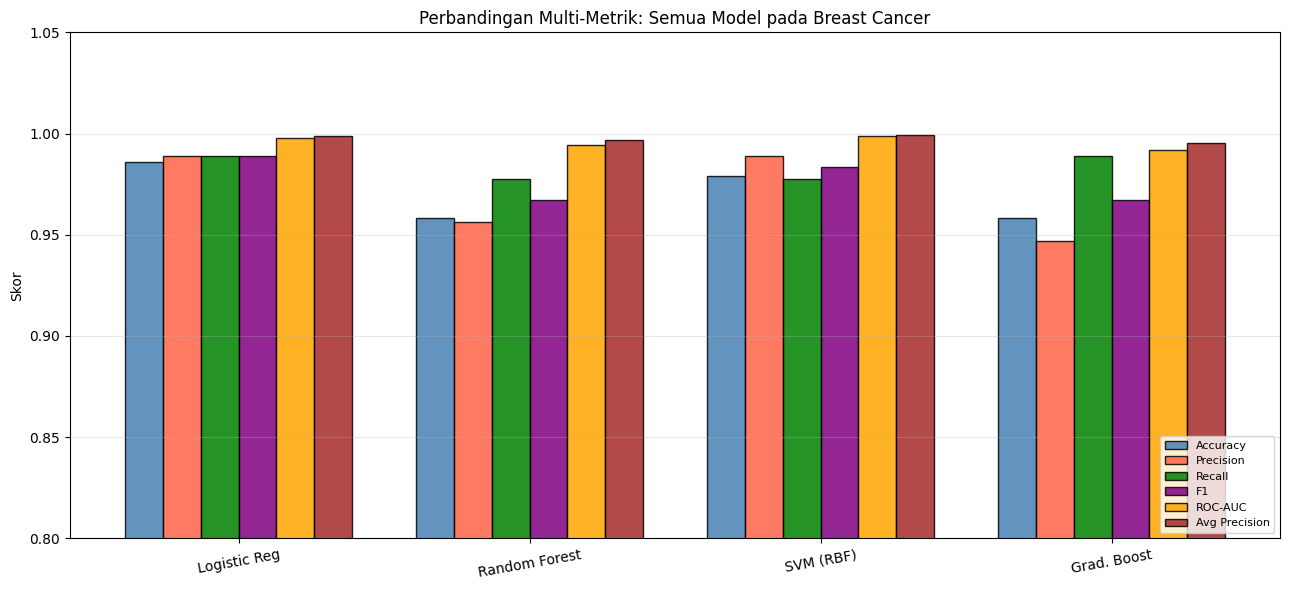

In [43]:
# Visualisasi perbandingan semua metrik dalam satu plot
models_compare = {
    "Logistic Reg": make_pipeline(StandardScaler(),
                                   LogisticRegression(max_iter=5000, C=1)),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0),
    "SVM (RBF)":    make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma=0.01,
                                                         probability=True)),
    "Grad. Boost":  GradientBoostingClassifier(n_estimators=100, random_state=0),
}

cancer2 = load_breast_cancer()
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    cancer2.data, cancer2.target, random_state=42, stratify=cancer2.target)

metrics_compare = {}
for name, model in models_compare.items():
    model.fit(X2_tr, y2_tr)
    y_p  = model.predict(X2_te)
    y_pr = model.predict_proba(X2_te)[:, 1]
    metrics_compare[name] = {
        "Accuracy":         model.score(X2_te, y2_te),
        "Precision":        precision_score(y2_te, y_p),
        "Recall":           recall_score(y2_te, y_p),
        "F1":               f1_score(y2_te, y_p),
        "ROC-AUC":          roc_auc_score(y2_te, y_pr),
        "Avg Precision":    average_precision_score(y2_te, y_pr),
    }

df_compare = pd.DataFrame(metrics_compare).T
print("Perbandingan semua metrik (Breast Cancer):")
print(df_compare.round(4).to_string())

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_compare))
width = 0.13
colors_m = ["steelblue", "tomato", "green", "purple", "orange", "brown"]

for i, (metric, color) in enumerate(zip(df_compare.columns, colors_m)):
    ax.bar(x + i*width, df_compare[metric], width,
           label=metric, color=color, alpha=0.85, edgecolor="black")

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(df_compare.index, rotation=10)
ax.set_ylabel("Skor")
ax.set_ylim(0.8, 1.05)
ax.set_title("Perbandingan Multi-Metrik: Semua Model pada Breast Cancer")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5.9 Ringkasan

### Cross-Validation

| Metode | Kapan Digunakan | Kelebihan |
|--------|----------------|-----------|
| KFold | Dataset regression | Sederhana, efisien |
| StratifiedKFold | Dataset klasifikasi | Jaga proporsi kelas per fold |
| ShuffleSplit | Dataset besar, butuh kontrol ukuran | Fleksibel |
| LOO | Dataset sangat kecil | Estimasi tidak bias |

### Hyperparameter Tuning

| Metode | Kapan Digunakan | Trade-off |
|--------|----------------|-----------|
| GridSearchCV | Ruang parameter kecil (< 100 kombinasi) | Exhaustive tapi lambat |
| RandomizedSearchCV | Ruang parameter besar | Lebih cepat, tidak exhaustive |

### Metrik Klasifikasi

| Metrik | Gunakan Ketika |
|--------|----------------|
| Accuracy | Kelas seimbang, semua kesalahan sama beratnya |
| Precision | Biaya FP tinggi (spam filter, rekomendasi produk) |
| Recall | Biaya FN tinggi (deteksi penyakit, fraud) |
| F1 Score | Butuh keseimbangan precision dan recall |
| ROC-AUC | Evaluasi di semua threshold, kelas relatif seimbang |
| PR-AUC | Dataset sangat tidak seimbang, kelas positif langka |

### Metrik Regresi

| Metrik | Kapan Digunakan |
|--------|----------------|
| R2 | Perbandingan relatif antar model |
| RMSE | Error besar lebih merugikan |
| MAE | Robust terhadap outlier |

### Tips Penting

1. Selalu gunakan StratifiedKFold untuk klasifikasi.
2. Jangan sentuh test set sampai evaluasi akhir.
3. GridSearchCV di dalam Pipeline mencegah data leakage.
4. Pilih metrik berdasarkan biaya relatif FP vs FN di domain masalahmu.
5. Untuk imbalanced dataset, accuracy bisa sangat menyesatkan.
